In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#task 1 to download dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"

#task 2 to read dataset as pandas dataframe
df = pd.read_csv(url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [2]:
#task 2B to show first 5 rows
df.head(5)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [10]:
#task 3 : to summarize the dataset , Report number of rows, columns, data types, missing values.

# to find now to rows and columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
# alternate method
print("-------------------RowsXcolumns[alternate methods]",df.shape)
# to get columns names
print("------------------Columns details : ",df.columns)
# to get alternate method for all details
print("------------------alternate method for all details : ", df.info)

# to see datatypes
print("------------------To see datatypes for each columns: ",df.dtypes)

Rows: 299
Columns: 13
-------------------RowsXcolumns[alternate methods] (299, 13)
------------------Columns details :  Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')
------------------alternate method for all details :  <bound method DataFrame.info of       age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0    75.0        0                       582         0                 20   
1    55.0        0                      7861         0                 38   
2    65.0        0                       146         0                 20   
3    50.0        1                       111         0                 20   
4    65.0        1                       160         1                 20   
..    ...      ...                       ...       ...                ...   
294  62.0   

In [12]:
# Visualize Missing Values: Create heatmap using seaborn to show missing values.
df.isnull().sum()

# since no missing value we will create a fake dataset to create missing value
clean_df = df.copy()
np.random.seed(42)

clean_df.loc[10:14, "serum_creatinine"] = np.nan
clean_df.loc[20:24, "age"] = np.nan
clean_df.loc[30:34, "smoking"] = np.nan

clean_df.isnull().sum()

,0
age,5
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,5
serum_sodium,0
sex,0


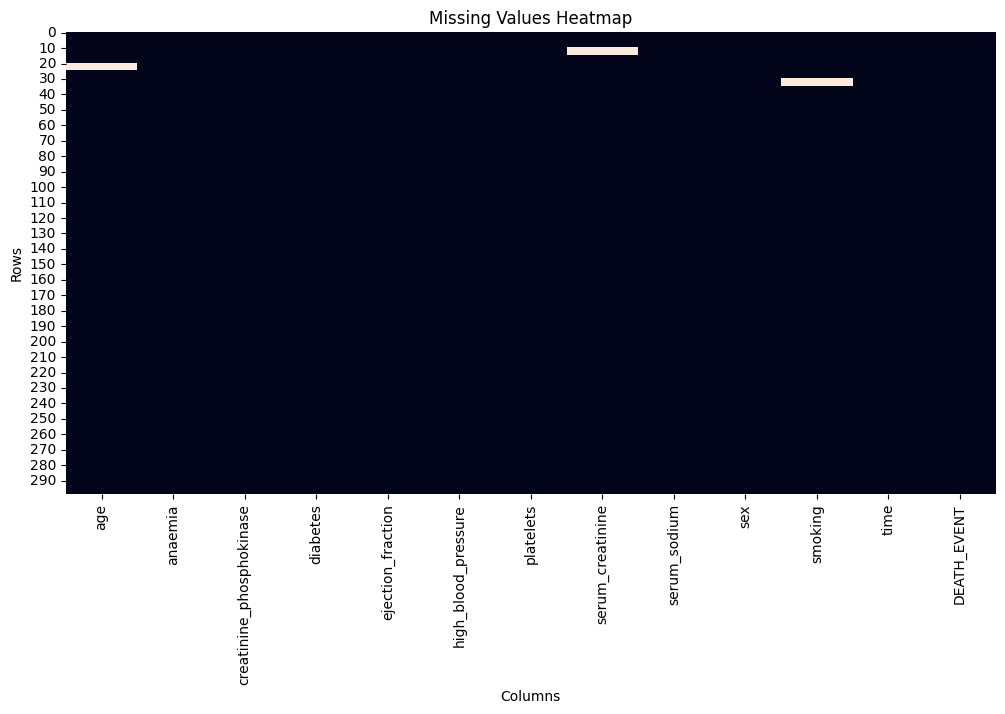

In [13]:
plt.figure(figsize=(12, 6))

sns.heatmap(clean_df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

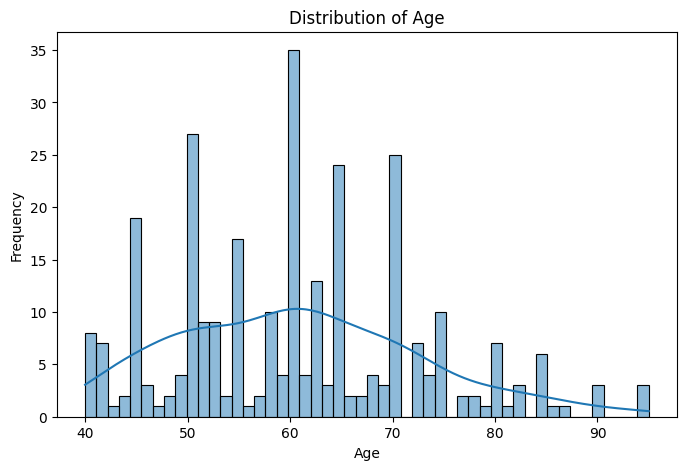

In [17]:
# creating histogram
plt.figure(figsize=(8, 5))

sns.histplot(clean_df["age"], bins=50, kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

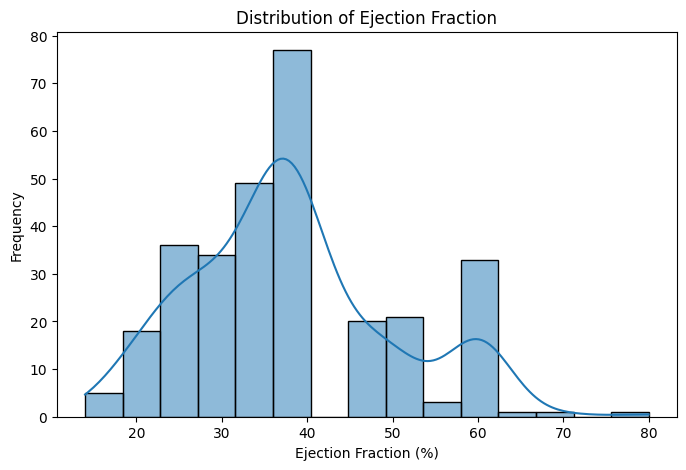

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(clean_df["ejection_fraction"], bins=15, kde=True)

plt.title("Distribution of Ejection Fraction")
plt.xlabel("Ejection Fraction (%)")
plt.ylabel("Frequency")

plt.show()

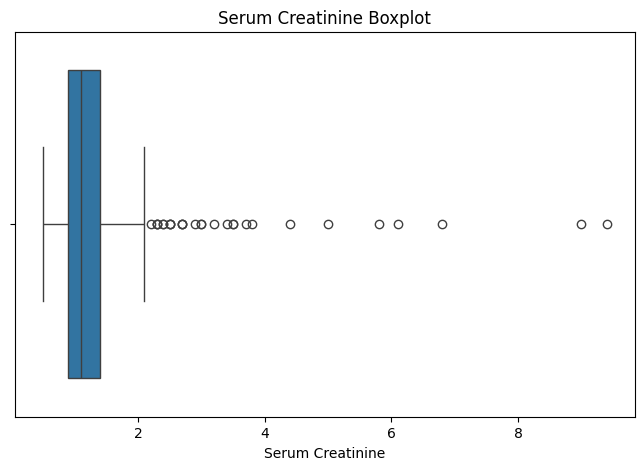

In [18]:
#box plots for outliers
plt.figure(figsize=(8, 5))

sns.boxplot(x=clean_df["serum_creatinine"])

plt.title("Serum Creatinine Boxplot")
plt.xlabel("Serum Creatinine")

plt.show()

In [19]:
# task 6: Impute Missing Values: • Numerical features: Use mean or median (e.g., serum_creatinine).
median_age = clean_df["age"].median()

print(median_age)

clean_df["age"] = clean_df["age"].fillna(median_age)

60.0


In [22]:
median_creatinine = clean_df["serum_creatinine"].median()

print(median_creatinine)

clean_df["serum_creatinine"] = clean_df["serum_creatinine"].fillna(median_creatinine)

1.1


In [23]:
mode_smoking = clean_df["smoking"].mode()[0]
clean_df["smoking"] = clean_df["smoking"].fillna(mode_smoking)


In [24]:
clean_df.isnull().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


In [27]:
# now outliers part
def remove_outliers_iqr(dataframe, column):

    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    filtered_df = dataframe[
        (dataframe[column] >= lower_bound) &
        (dataframe[column] <= upper_bound)
    ]

    return filtered_df

outlier_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]

for column in outlier_columns:
    clean_df = remove_outliers_iqr(clean_df, column)

In [30]:
# task 8: Correct Inconsistencies: Check and fix invalid entries (e.g., negative age).
print(clean_df["age"].min())

clean_df.loc[clean_df["age"] < 0, "age"] = np.nan
clean_df["age"] = clean_df["age"].fillna(
    clean_df["age"].median()
)

40.0


In [31]:
binary_columns = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking",
    "DEATH_EVENT"
]

for column in binary_columns:
    print(column, clean_df[column].unique())

anaemia [0 1]
diabetes [0 1]
high_blood_pressure [1 0]
sex [1 0]
smoking [0. 1.]
DEATH_EVENT [1 0]


In [33]:
# task 9. Feature Engineering:
# • Create age_group feature (bins: <40, 40–60, >60).
# • Create risk_score feature (e.g., normalized product of ejection_fraction,
# serum_creatinine).
bins = [0, 40, 60, float("inf")]

labels = [
    "<40",
    "40-60",
    ">60"
]

clean_df["age_group"] = pd.cut(
    clean_df["age"],
    bins=bins,
    labels=labels,
    right=False
)

clean_df[["age", "age_group"]].head(10)

,age,age_group
0,75.0,>60
2,65.0,>60
3,50.0,40-60
6,75.0,>60
8,65.0,>60
10,75.0,>60
11,62.0,>60
12,45.0,40-60
13,50.0,40-60
14,49.0,40-60


In [37]:
clean_df["ef_normalized"] = (
    clean_df["ejection_fraction"] -
    clean_df["ejection_fraction"].min()
) / (
    clean_df["ejection_fraction"].max() -
    clean_df["ejection_fraction"].min()
)

clean_df["creatinine_normalized"] = (
    clean_df["serum_creatinine"] -
    clean_df["serum_creatinine"].min()
) / (
    clean_df["serum_creatinine"].max() -
    clean_df["serum_creatinine"].min()
)

clean_df["risk_score"] = (
    clean_df["ef_normalized"] *
    clean_df["creatinine_normalized"]
)

In [38]:
# 10. Encode Categorical Variables: Apply one-hot or label encoding to categorical features (e.g.,sex, smoking).
clean_df = pd.get_dummies(
    clean_df,
    columns=["age_group"],
    dtype=int
)

In [40]:
#11. Normalize Features: Scale numerical features (e.g., age, platelets) to 0–1 using MinMaxScaler.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
numerical_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

In [41]:
#Compute Summary Statistics BEFORE Cleaning
numerical_columns_original = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]
df[numerical_columns_original].mean()
df[numerical_columns_original].median()
df[numerical_columns_original].std()

before_stats = df[numerical_columns_original].agg(
    ["mean", "median", "std"]
)

before_stats

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
mean,60.833893,581.839465,38.083612,263358.029264,1.39388,136.625418,130.260870
median,60.000000,250.000000,38.000000,262000.000000,1.10000,137.000000,115.000000
std,11.894809,970.287881,11.834841,97804.236869,1.03451,4.412477,77.614208


In [43]:
cleaned_before_scaling = clean_df.copy()
after_stats = cleaned_before_scaling[
    numerical_columns_original
].agg(["mean", "median", "std"])

after_stats
print("BEFORE CLEANING")
display(before_stats)

print("\nAFTER CLEANING")
display(after_stats)

difference = after_stats - before_stats

difference

BEFORE CLEANING


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
mean,60.833893,581.839465,38.083612,263358.029264,1.39388,136.625418,130.260870
median,60.000000,250.000000,38.000000,262000.000000,1.10000,137.000000,115.000000
std,11.894809,970.287881,11.834841,97804.236869,1.03451,4.412477,77.614208



AFTER CLEANING


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
mean,60.506009,334.599099,0.475358,255958.570135,0.397436,137.085586,132.585586
median,60.000000,211.500000,0.470588,262500.000000,0.384615,137.000000,120.000000
std,11.725952,279.366570,0.229950,67410.181249,0.237304,3.795314,76.842728


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
mean,-0.327884,-247.240366,-37.608254,-7399.459129,-0.996444,0.460168,2.324716
median,0.000000,-38.500000,-37.529412,500.000000,-0.715385,0.000000,5.000000
std,-0.168857,-690.921311,-11.604891,-30394.055620,-0.797207,-0.617164,-0.771480


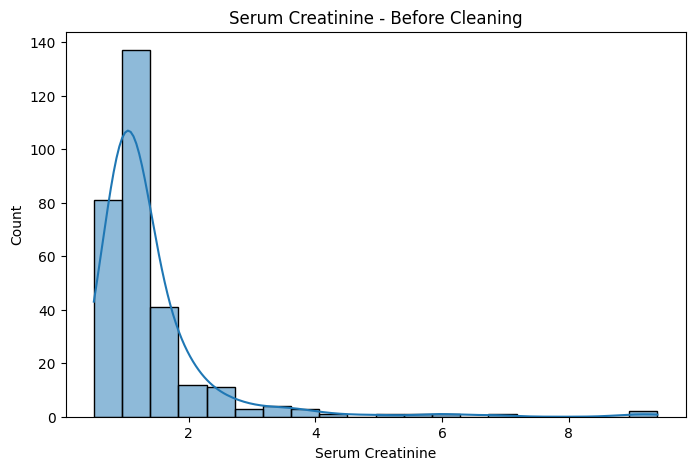

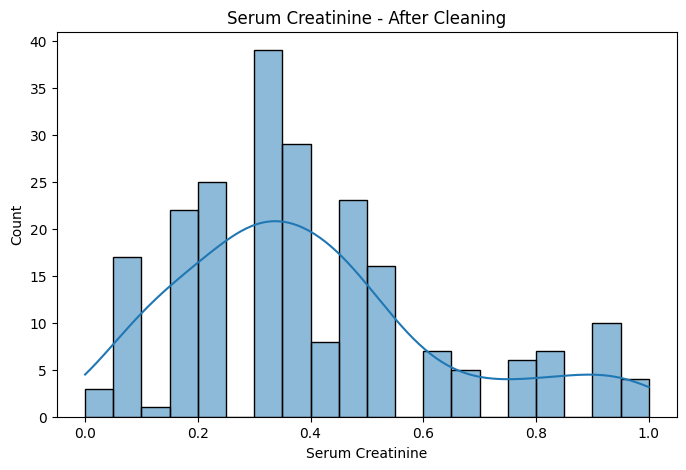

In [45]:
# step 13: Validate Cleaning: Plot histograms or boxplots for cleaned numerical features.
# step 14. Check Missing Values: Confirm no missing values remain or justify any remaining.
plt.figure(figsize=(8, 5))

sns.histplot(
    df["serum_creatinine"],
    bins=20,
    kde=True
)

plt.title("Serum Creatinine - Before Cleaning")
plt.xlabel("Serum Creatinine")
plt.show()

plt.figure(figsize=(8, 5))

sns.histplot(
    cleaned_before_scaling["serum_creatinine"],
    bins=20,
    kde=True
)

plt.title("Serum Creatinine - After Cleaning")
plt.xlabel("Serum Creatinine")
plt.show()

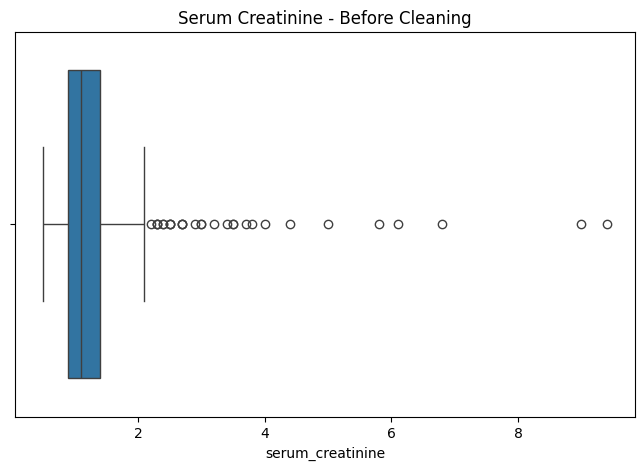

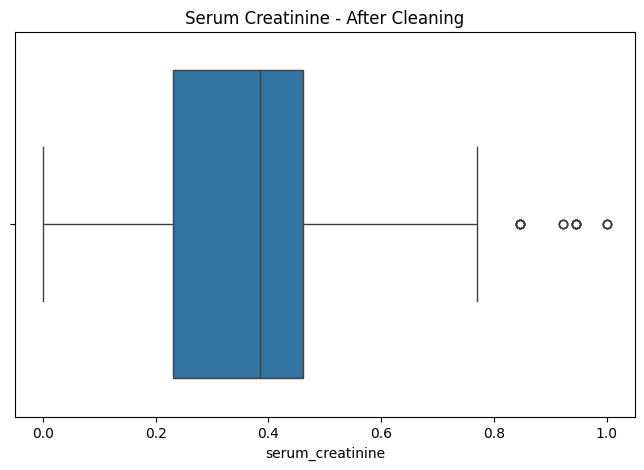

In [46]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["serum_creatinine"])

plt.title("Serum Creatinine - Before Cleaning")

plt.show()

plt.figure(figsize=(8, 5))

sns.boxplot(x=cleaned_before_scaling["serum_creatinine"])

plt.title("Serum Creatinine - After Cleaning")

plt.show()

In [49]:
if clean_df.isnull().sum().sum() == 0:
    print("No missing values remain.")
else:
    print("Missing values still exist.")

clean_df.head()

No missing values remain.


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,ef_normalized,creatinine_normalized,risk_score,age_group_<40,age_group_40-60,age_group_>60
0,75.0,0,582,0,0.117647,1,265000.00,1.000000,130,1,0.0,4,1,0.117647,1.000000,0.117647,0,0,1
2,65.0,0,146,0,0.117647,0,162000.00,0.538462,129,1,1.0,7,1,0.117647,0.538462,0.063348,0,0,1
3,50.0,1,111,0,0.117647,0,210000.00,1.000000,137,1,0.0,7,1,0.117647,1.000000,0.117647,0,1,0
6,75.0,1,246,0,0.019608,0,127000.00,0.461538,137,1,0.0,10,1,0.019608,0.461538,0.009050,0,0,1
8,65.0,0,157,0,1.000000,0,263358.03,0.692308,138,0,0.0,10,1,1.000000,0.692308,0.692308,0,0,1
